PROJETO: PREVISAO DE SERIE TEMPORAL
Comparacao entre ARIMA, Prophet e LSTM

1. CARREGAMENTO DA BASE DE DADOS

Amostra inicial:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121
5  1949-06         135
6  1949-07         148
7  1949-08         148

Amostra final:
       Month  Passengers
136  1960-05         472
137  1960-06         535
138  1960-07         622
139  1960-08         606
140  1960-09         508
141  1960-10         461
142  1960-11         390
143  1960-12         432

Base carregada com 144 registros.
Periodo: 1949-01-01 a 1960-12-01
Frequencia: mensal

2. ESTATISTICAS DESCRITIVAS
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: valor, dtype: float64

Resumo da serie:
- Media: 280.30
- Mediana: 265.50
- Desvio padrao: 119.97
- Coeficiente de variacao: 42.80%
- Amplitude

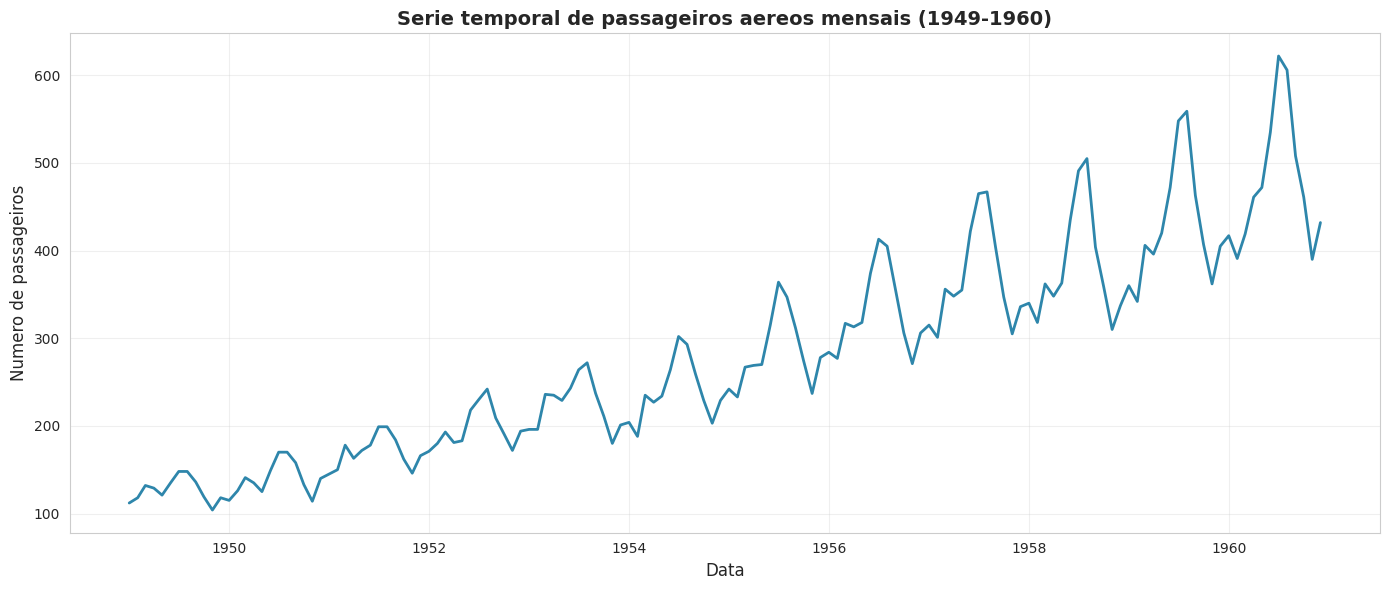


Figura salva: 01_serie_temporal_completa.png

Observacoes principais:
1. Ha uma tendencia ascendente bem definida.
2. A sazonalidade anual e visivel ao longo de toda a serie.
3. A amplitude dos picos aumenta com o tempo, o que sugere variancia nao constante.

Essas caracteristicas justificam a avaliacao de modelos lineares e nao lineares,
especialmente aqueles adequados a series com sazonalidade.


5. DISTRIBUICAO E POSSIVEIS OUTLIERS


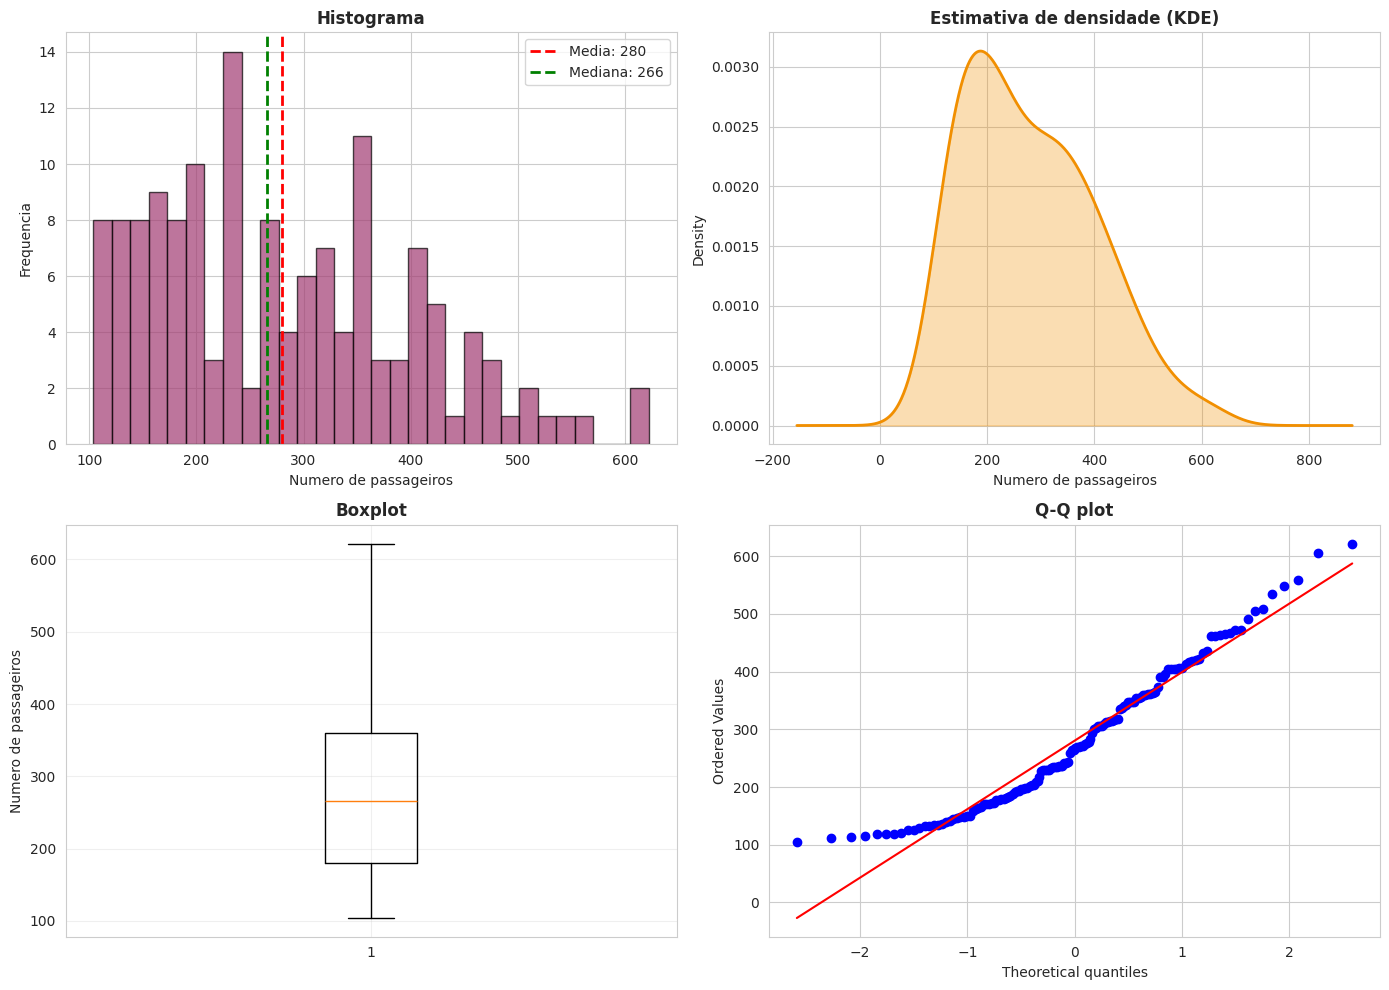

Figura salva: 02_analise_distribuicao.png

Analise por IQR:
- Q1: 180
- Q3: 360
- IQR: 180
- Limite inferior: -91
- Limite superior: 631
- Total de pontos fora dos limites: 0

Em series temporais, observacoes extremas nem sempre representam erro.
Neste caso, a serie e curta e os picos fazem parte do padrao sazonal,
por isso a decisao mais prudente e mante-los na analise.


6. TESTE ADF
Estatistica de teste: 0.815369
P-value: 0.991880
Lags utilizados: 13
Numero de observacoes: 130

Valores criticos:
  1%: -3.482
  5%: -2.884
  10%: -2.579

A serie nao e estacionaria; sera necessario diferenciar.

7. DIFERENCIACAO DA SERIE
P-value apos a primeira diferenca: 0.054213
A serie ainda nao ficou estacionaria; sera avaliada uma segunda diferenca.
P-value apos a segunda diferenca: 0.000000


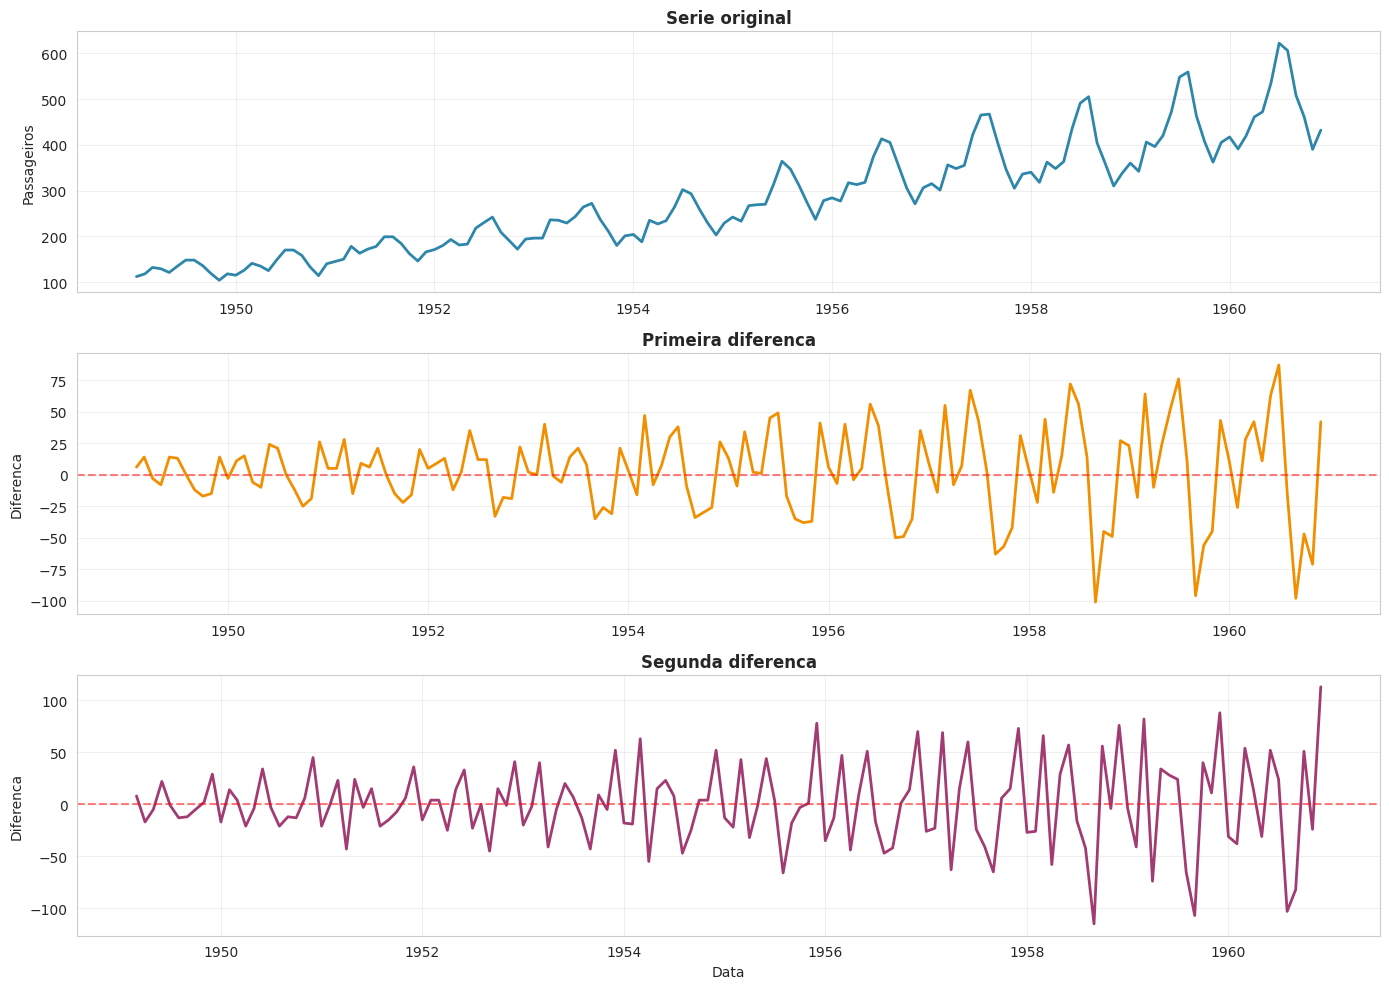

Figura salva: 03_diferenciacao.png
Parametro d adotado para o ARIMA: 2

8. ACF E PACF


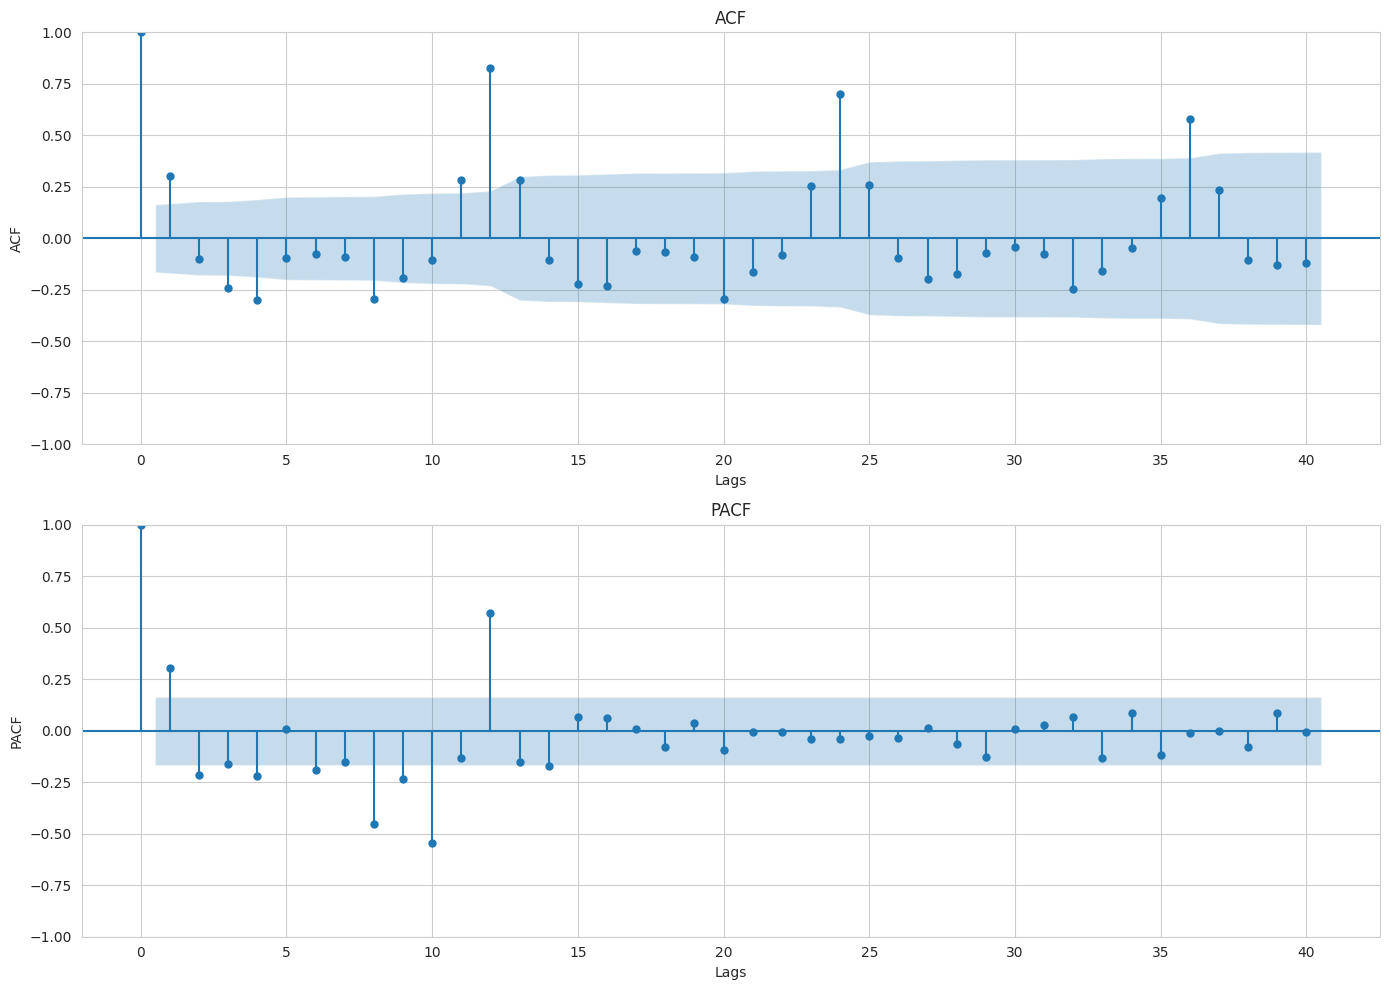

Figura salva: 04_acf_pacf.png

Leitura dos graficos:
- A ACF ajuda a identificar o componente de media movel (q).
- A PACF auxilia na identificacao do componente autoregressivo (p).
- A combinacao dos dois graficos, junto com o teste ADF, orienta a escolha do ARIMA.

Para fins deste estudo, adota-se uma configuracao inicial simples e interpretavel.


9. DIVISAO TREINO E TESTE
Tamanho da base: 144
Treino: 115
Teste: 29


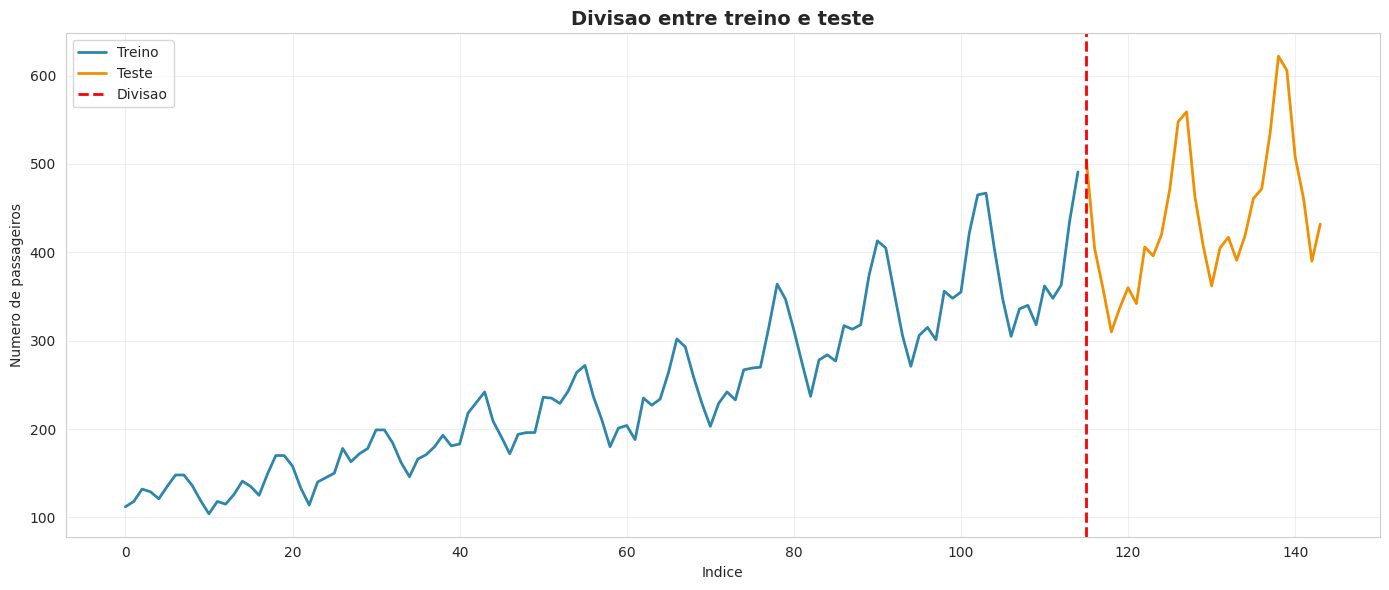

Figura salva: 05_divisao_treino_teste.png

10. MODELO ARIMA
Configuracao inicial: ARIMA(1, 1, 1)

Resumo do modelo ARIMA:
                               SARIMAX Results                                
Dep. Variable:                  valor   No. Observations:                  115
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -526.123
Date:                Tue, 16 Jun 2026   AIC                           1058.246
Time:                        20:46:00   BIC                           1066.454
Sample:                             0   HQIC                          1061.577
                                - 115                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5111      0.114     -4.488      0.000      -0.734      -0.288
ma.L1    

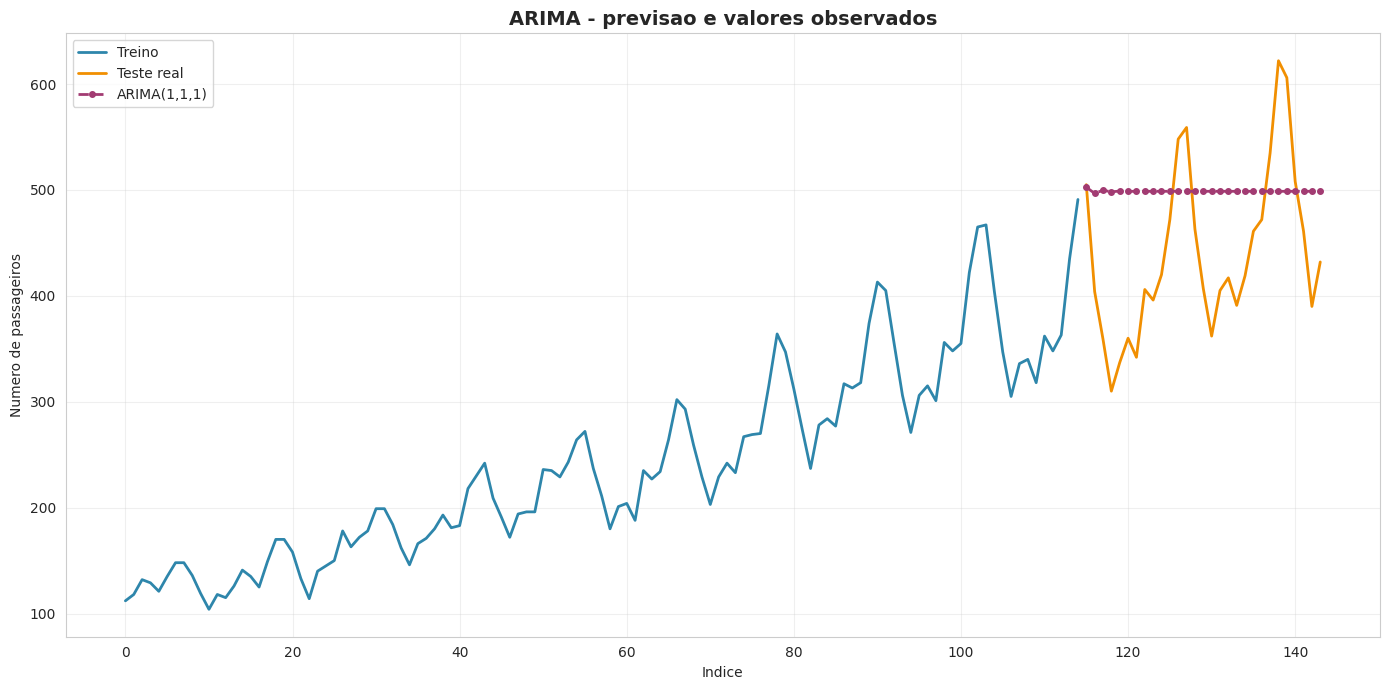

Figura salva: 06_arima_resultado.png

11. MODELO PROPHET

Prophet e apropriado neste contexto porque modela tendencia e sazonalidade
de forma automatica, sem exigir estacionariedade previa.

MAE:  33.89
RMSE: 41.33
MAPE: 7.72%


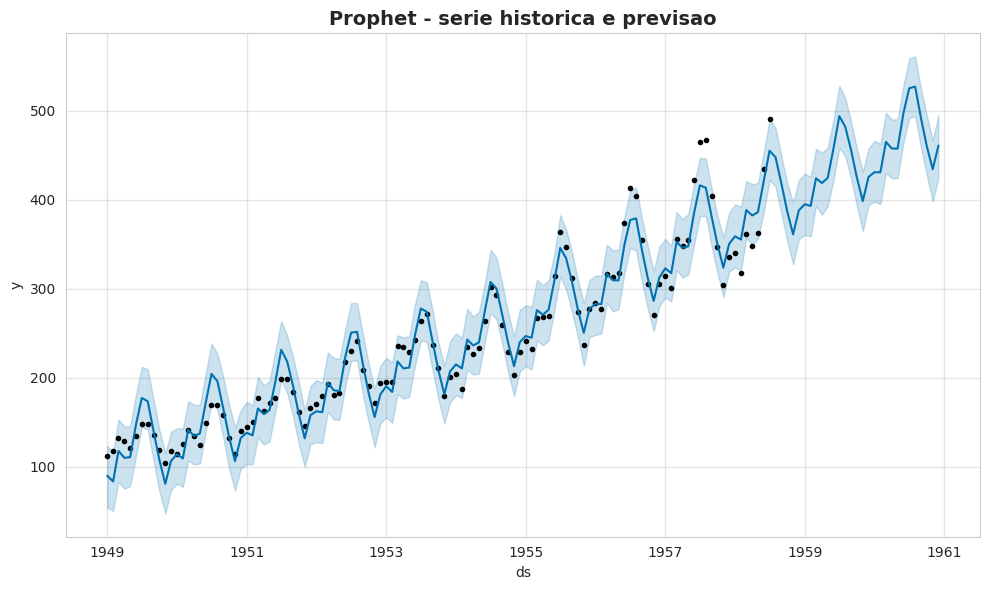

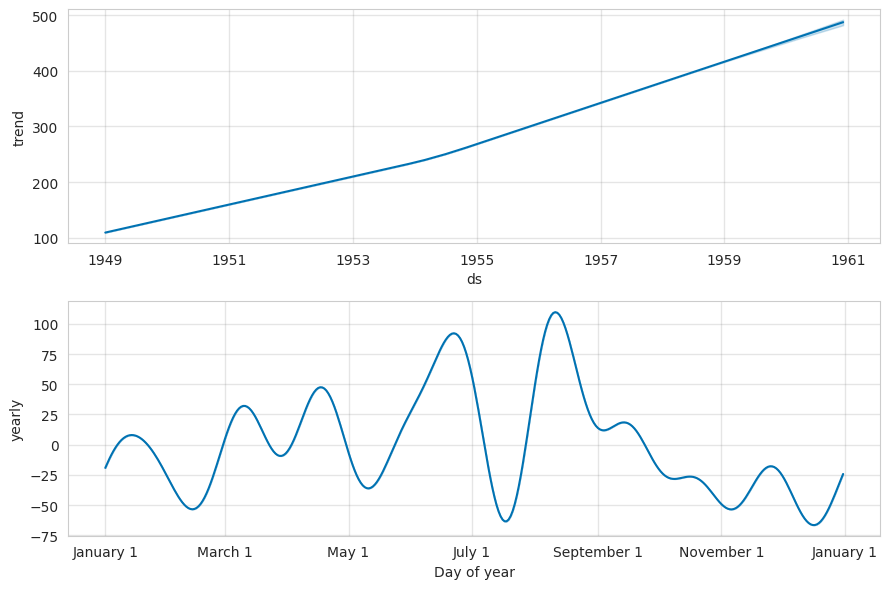

Figuras salvas: 07_prophet_completo.png e 08_prophet_componentes.png


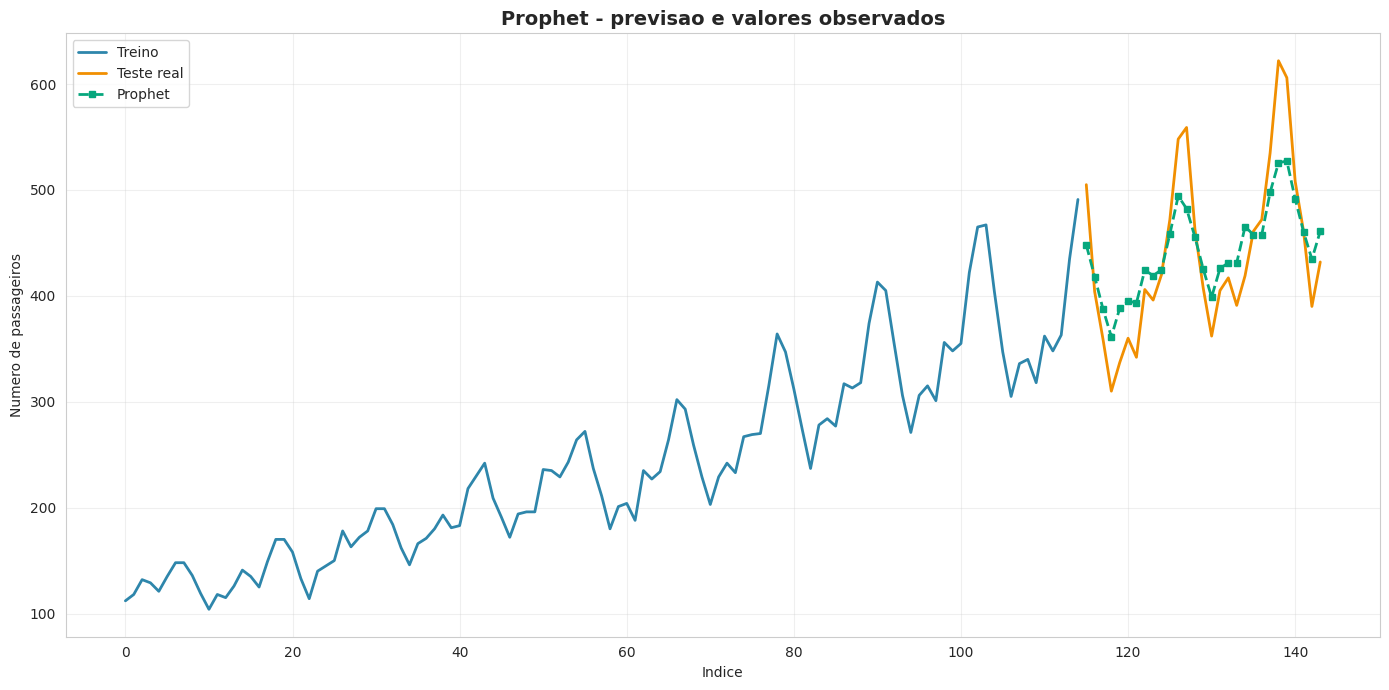

Figura salva: 09_prophet_resultado.png

12. MODELO LSTM - PREPARACAO DOS DADOS

O uso de LSTM permite investigar se um modelo de aprendizado profundo
consegue capturar relacoes nao lineares na serie. Como a base e pequena,
essa etapa serve mais para comparacao metodologica do que para expectativa
de superioridade automatica.

Sequencias criadas: 132
Janela temporal (look_back): 12
X_train shape: (105, 12, 1)
X_test shape: (27, 12, 1)

13. MODELO LSTM - TREINAMENTO
Treinamento concluido com sucesso.


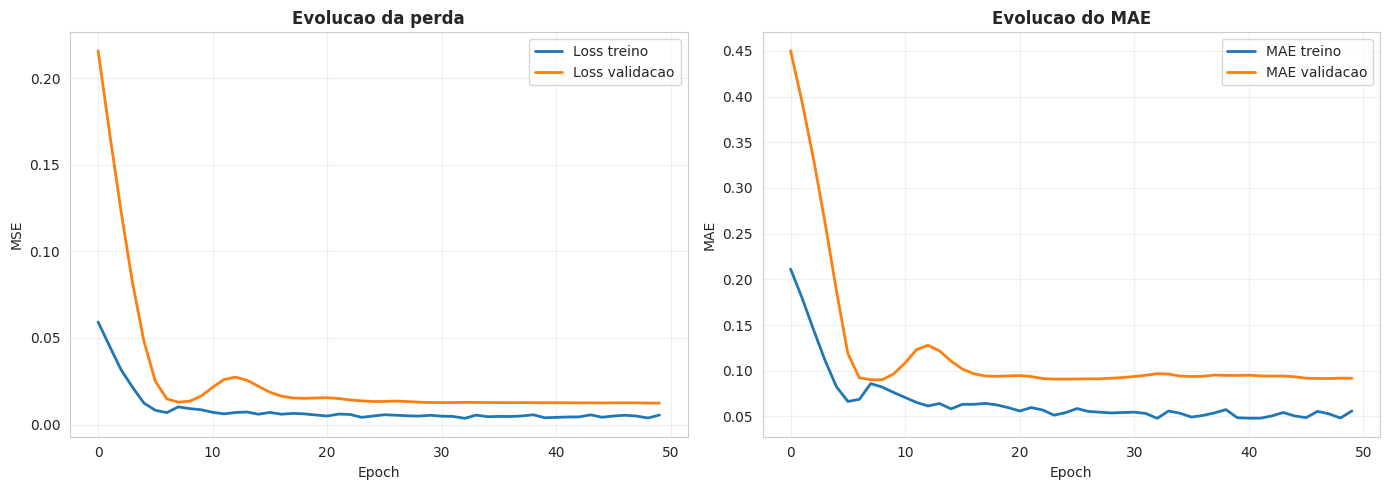

Figura salva: 10_lstm_treinamento.png

14. MODELO LSTM - PREVISAO E AVALIACAO
MAE:  58.98
RMSE: 71.74
MAPE: 13.60%


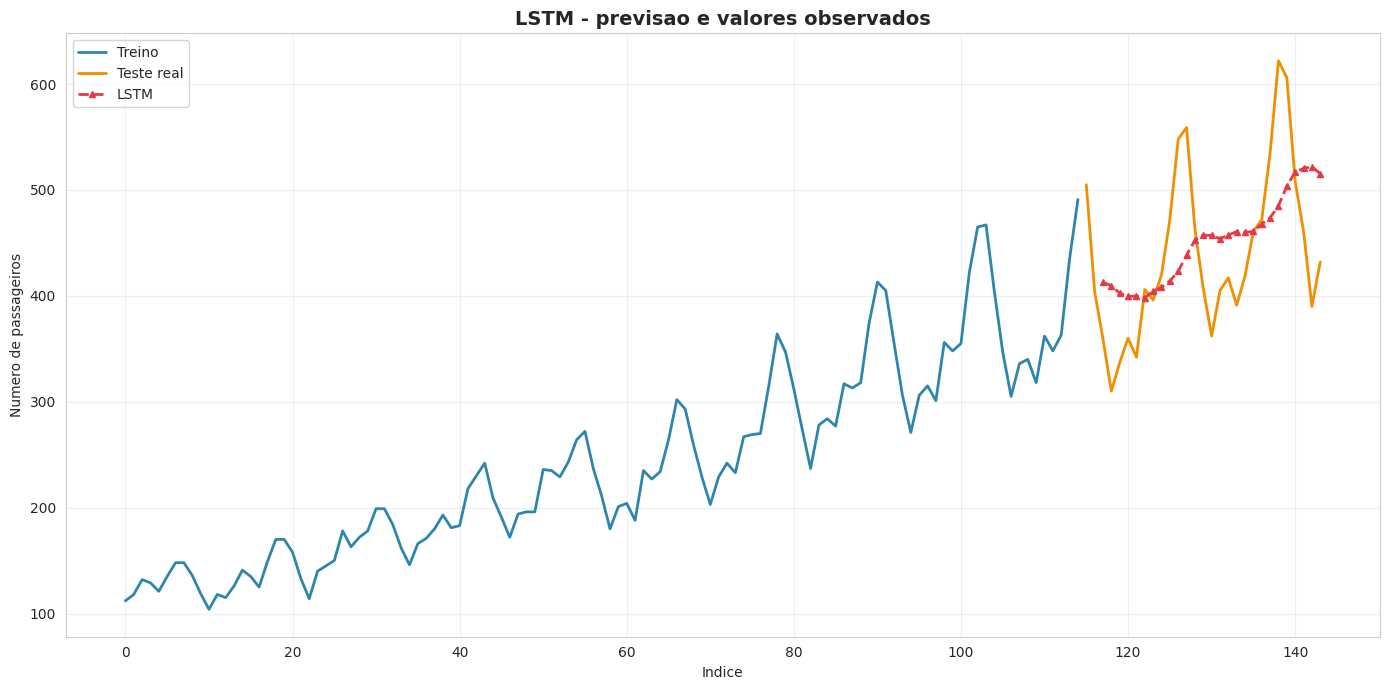

Figura salva: 11_lstm_resultado.png

15. COMPARACAO ENTRE MODELOS
      Modelo       MAE      RMSE  MAPE (%)
ARIMA(1,1,1) 85.254156 97.499620 21.291349
     Prophet 33.893128 41.330542  7.719160
        LSTM 58.978459 71.742431 13.603992

Tabela salva: resultados_comparacao.csv


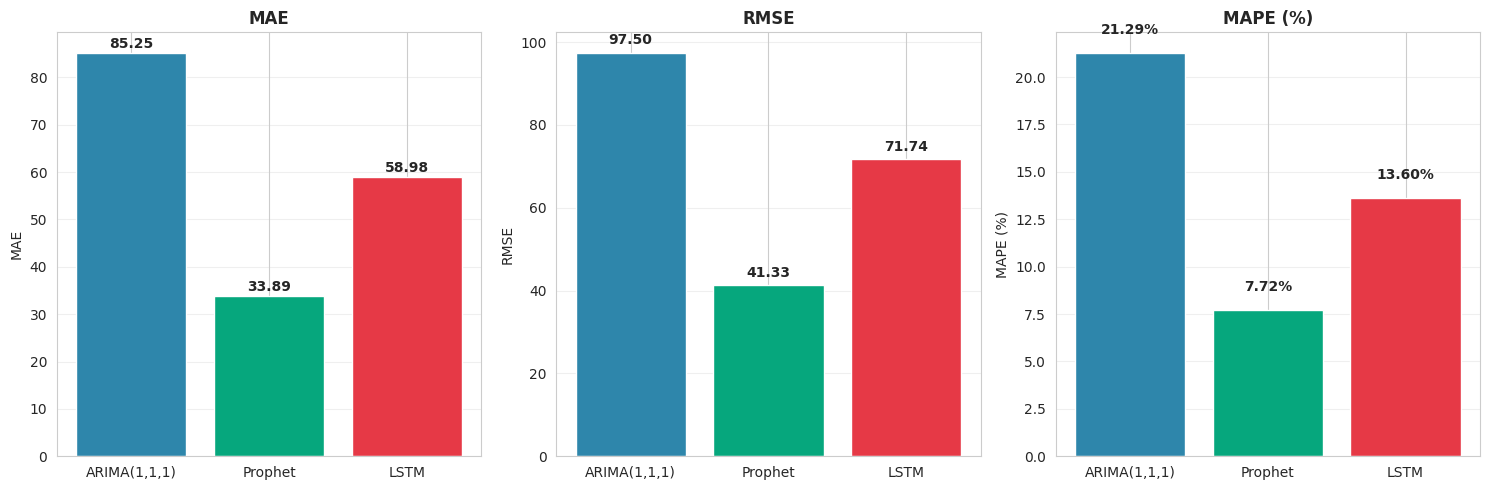

Figura salva: 12_comparacao_modelos.png

Leitura comparativa:
- Melhor MAE: Prophet
- Melhor RMSE: Prophet

No contexto deste estudo, o RMSE recebe destaque por penalizar mais fortemente
erros grandes, o que e util quando se deseja previsoes mais consistentes
em picos sazonais.


16. COMPARACAO FINAL DAS PREVISOES


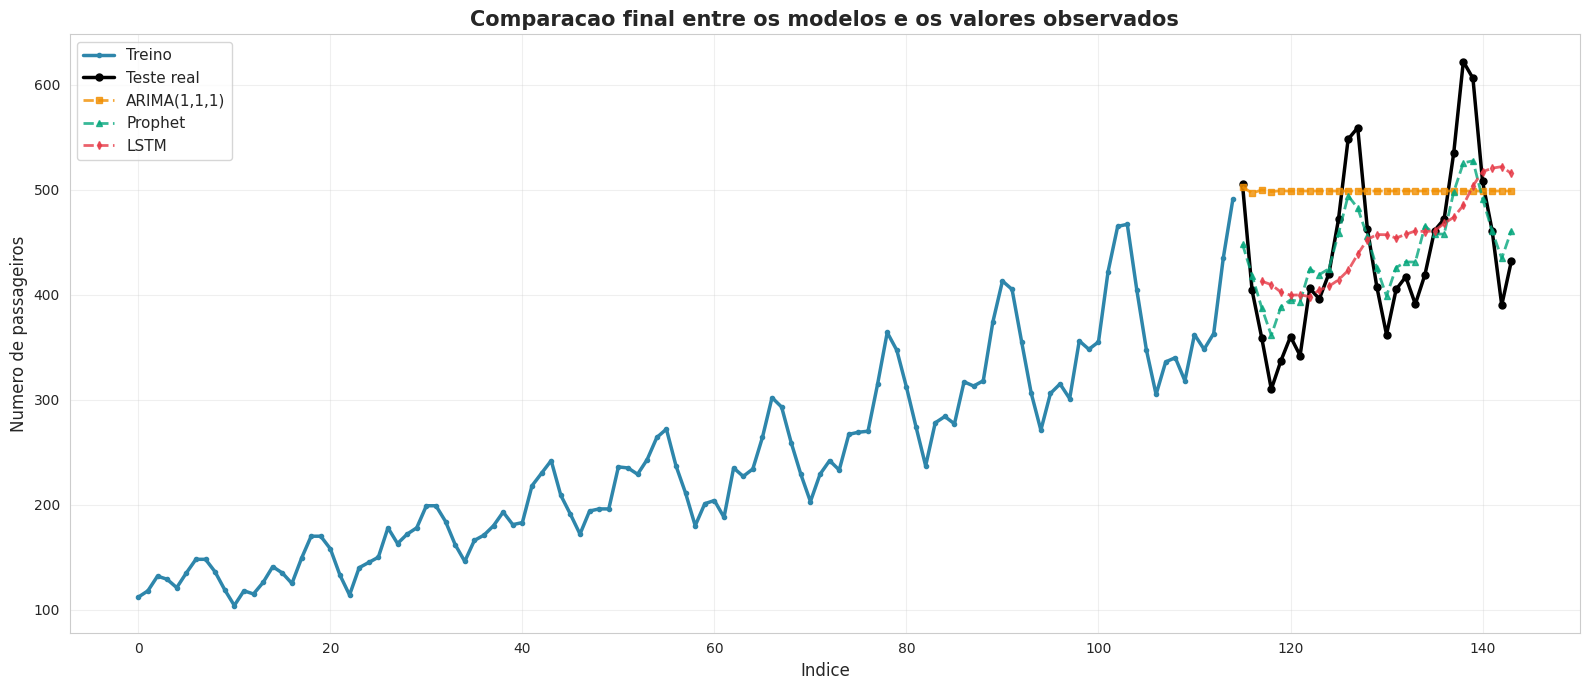

Figura salva: 13_comparacao_final.png

17. DISCUSSAO FINAL

1. Caracterizacao da serie
- Tendencia crescente de 1949 a 1960.
- Sazonalidade anual marcada.
- Variabilidade crescente ao longo do tempo.

2. Estacionariedade
- O teste ADF indicou nao estacionariedade na serie original.
- A primeira diferenca foi suficiente para estabilizar a media.

3. Modelagem
- ARIMA: interpretavel e adequado a series com estrutura linear.
- Prophet: robusto para tendencia e sazonalidade.
- LSTM: flexivel, mas sensivel ao tamanho reduzido da base.

4. Resultados
- MAE:
  * ARIMA(1,1,1): 85.25
  * Prophet: 33.89
  * LSTM: 58.98
- RMSE:
  * ARIMA(1,1,1): 97.50
  * Prophet: 41.33
  * LSTM: 71.74

5. Interpretacao metodologica
O melhor desempenho pelo RMSE foi obtido por Prophet.
Esse resultado sugere que, para uma serie historica curta e com padrao sazonal
regular, modelos estatisticos continuam sendo uma referencia bastante solida.

6. Limitacoes
- A serie contem apenas 144 observacoes.
- Nao foram realiz

In [7]:
# ==============================================================================
# PROJETO APLICADO IV
# Analise e previsao de serie temporal
#
# Modelos comparados:
# - ARIMA
# - Prophet
# - LSTM
#
# Observacao:
# Este arquivo foi organizado para execucao sequencial, como em um notebook.
# ==============================================================================

# %%
# ==============================================================================
# 0. DEPENDENCIAS
# ==============================================================================
"""
Dependencias sugeridas:

pip install pandas numpy scikit-learn tensorflow statsmodels prophet matplotlib seaborn scipy

Se houver dificuldade na instalacao do Prophet:
pip install cmdstanpy prophet
"""

# %%
# ==============================================================================
# 1. IMPORTS E CONFIGURACAO
# ==============================================================================

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)


def secao(numero: int, titulo: str) -> None:
    print("\n" + "=" * 80)
    print(f"{numero}. {titulo}")
    print("=" * 80)


def paragrafo(texto: str) -> None:
    print("\n" + texto.strip() + "\n")


print("=" * 80)
print("PROJETO: PREVISAO DE SERIE TEMPORAL")
print("Comparacao entre ARIMA, Prophet e LSTM")
print("=" * 80)

# %%
# ==============================================================================
# 2. CARREGAMENTO DA BASE
# ==============================================================================

secao(1, "CARREGAMENTO DA BASE DE DADOS")

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

print("\nAmostra inicial:")
print(df.head(8))

print("\nAmostra final:")
print(df.tail(8))

df.columns = ["data", "valor"]
df["data"] = pd.to_datetime(df["data"])
df = df.sort_values("data").reset_index(drop=True)

print(f"\nBase carregada com {len(df)} registros.")
print(
    f"Periodo: {df['data'].min().strftime('%Y-%m-%d')} a {df['data'].max().strftime('%Y-%m-%d')}"
)
print("Frequencia: mensal")

# %%
# ==============================================================================
# 3. ANALISE DESCRITIVA
# ==============================================================================

secao(2, "ESTATISTICAS DESCRITIVAS")

estatisticas = df["valor"].describe()
print(estatisticas)

media = df["valor"].mean()
mediana = df["valor"].median()
desvio = df["valor"].std()
minimo = df["valor"].min()
maximo = df["valor"].max()
amplitude = maximo - minimo
cv = (desvio / media) * 100

paragrafo(
    f"""
Resumo da serie:
- Media: {media:.2f}
- Mediana: {mediana:.2f}
- Desvio padrao: {desvio:.2f}
- Coeficiente de variacao: {cv:.2f}%
- Amplitude: {amplitude:.2f}

Em termos descritivos, a serie apresenta variabilidade elevada e tendencia
de crescimento ao longo do periodo analisado. Esse comportamento costuma
exigir modelos capazes de representar tendencia e sazonalidade.
"""
)

# %%
# ==============================================================================
# 4. QUALIDADE DOS DADOS
# ==============================================================================

secao(3, "VERIFICACAO DE VALORES AUSENTES E DUPLICIDADES")

nulos = df["valor"].isna().sum()
duplicatas = df.duplicated().sum()

print(f"Valores ausentes: {nulos}")
print(f"Registros duplicados: {duplicatas}")

if nulos == 0 and duplicatas == 0:
    print("\nA base nao apresenta inconsistencias evidentes.")
else:
    print("\nForam encontrados registros inconsistentes. Aplicando limpeza basica...")
    df = df.dropna().drop_duplicates().reset_index(drop=True)
    print(f"Total de registros apos a limpeza: {len(df)}")

# %%
# ==============================================================================
# 5. VISUALIZACAO DA SERIE
# ==============================================================================

secao(4, "SERIE TEMPORAL COMPLETA")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["data"], df["valor"], linewidth=2, color="#2E86AB")
ax.set_title("Serie temporal de passageiros aereos mensais (1949-1960)", fontsize=14, fontweight="bold")
ax.set_xlabel("Data", fontsize=12)
ax.set_ylabel("Numero de passageiros", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("01_serie_temporal_completa.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nFigura salva: 01_serie_temporal_completa.png")

paragrafo(
    """
Observacoes principais:
1. Ha uma tendencia ascendente bem definida.
2. A sazonalidade anual e visivel ao longo de toda a serie.
3. A amplitude dos picos aumenta com o tempo, o que sugere variancia nao constante.

Essas caracteristicas justificam a avaliacao de modelos lineares e nao lineares,
especialmente aqueles adequados a series com sazonalidade.
"""
)

# %%
# ==============================================================================
# 6. DISTRIBUICAO E OUTLIERS
# ==============================================================================

secao(5, "DISTRIBUICAO E POSSIVEIS OUTLIERS")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["valor"], bins=30, color="#A23B72", edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Histograma", fontweight="bold")
axes[0, 0].set_xlabel("Numero de passageiros")
axes[0, 0].set_ylabel("Frequencia")
axes[0, 0].axvline(media, color="red", linestyle="--", linewidth=2, label=f"Media: {media:.0f}")
axes[0, 0].axvline(mediana, color="green", linestyle="--", linewidth=2, label=f"Mediana: {mediana:.0f}")
axes[0, 0].legend()

df["valor"].plot(kind="kde", ax=axes[0, 1], color="#F18F01", linewidth=2)
axes[0, 1].set_title("Estimativa de densidade (KDE)", fontweight="bold")
axes[0, 1].set_xlabel("Numero de passageiros")
line = axes[0, 1].get_lines()[0]
axes[0, 1].fill_between(line.get_xdata(), line.get_ydata(), alpha=0.3, color="#F18F01")

axes[1, 0].boxplot(df["valor"], vert=True)
axes[1, 0].set_title("Boxplot", fontweight="bold")
axes[1, 0].set_ylabel("Numero de passageiros")
axes[1, 0].grid(True, alpha=0.3)

from scipy import stats

stats.probplot(df["valor"], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot", fontweight="bold")

plt.tight_layout()
plt.savefig("02_analise_distribuicao.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 02_analise_distribuicao.png")

Q1 = df["valor"].quantile(0.25)
Q3 = df["valor"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df[(df["valor"] < limite_inferior) | (df["valor"] > limite_superior)]

paragrafo(
    f"""
Analise por IQR:
- Q1: {Q1:.0f}
- Q3: {Q3:.0f}
- IQR: {IQR:.0f}
- Limite inferior: {limite_inferior:.0f}
- Limite superior: {limite_superior:.0f}
- Total de pontos fora dos limites: {len(outliers)}

Em series temporais, observacoes extremas nem sempre representam erro.
Neste caso, a serie e curta e os picos fazem parte do padrao sazonal,
por isso a decisao mais prudente e mante-los na analise.
"""
)

# %%
# ==============================================================================
# 7. TESTE DE ESTACIONARIEDADE
# ==============================================================================

secao(6, "TESTE ADF")

from statsmodels.tsa.stattools import adfuller

resultado_adf = adfuller(df["valor"], autolag="AIC")

print(f"Estatistica de teste: {resultado_adf[0]:.6f}")
print(f"P-value: {resultado_adf[1]:.6f}")
print(f"Lags utilizados: {resultado_adf[2]}")
print(f"Numero de observacoes: {resultado_adf[3]}")
print("\nValores criticos:")
for chave, valor in resultado_adf[4].items():
    print(f"  {chave}: {valor:.3f}")

if resultado_adf[1] < 0.05:
    print("\nA serie rejeita a hipotese nula de raiz unitaria.")
    d_necessario = 0
else:
    print("\nA serie nao e estacionaria; sera necessario diferenciar.")
    d_necessario = 1

# %%
# ==============================================================================
# 8. DIFERENCIACAO
# ==============================================================================

secao(7, "DIFERENCIACAO DA SERIE")

df["valor_diff1"] = df["valor"].diff()
resultado_adf_diff = adfuller(df["valor_diff1"].dropna(), autolag="AIC")

print(f"P-value apos a primeira diferenca: {resultado_adf_diff[1]:.6f}")

if resultado_adf_diff[1] < 0.05:
    print("A primeira diferenca foi suficiente para alcancar estacionariedade.")
    d_necessario = 1
else:
    print("A serie ainda nao ficou estacionaria; sera avaliada uma segunda diferenca.")
    df["valor_diff2"] = df["valor_diff1"].diff()
    resultado_adf_diff2 = adfuller(df["valor_diff2"].dropna(), autolag="AIC")
    print(f"P-value apos a segunda diferenca: {resultado_adf_diff2[1]:.6f}")
    d_necessario = 2

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df["data"], df["valor"], color="#2E86AB", linewidth=2)
axes[0].set_title("Serie original", fontweight="bold")
axes[0].set_ylabel("Passageiros")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["data"], df["valor_diff1"], color="#F18F01", linewidth=2)
axes[1].set_title("Primeira diferenca", fontweight="bold")
axes[1].set_ylabel("Diferenca")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[1].grid(True, alpha=0.3)

if "valor_diff2" in df.columns:
    axes[2].plot(df["data"], df["valor_diff2"], color="#A23B72", linewidth=2)
    axes[2].set_title("Segunda diferenca", fontweight="bold")
    axes[2].set_ylabel("Diferenca")
else:
    axes[2].axis("off")
    axes[2].text(
        0.5,
        0.5,
        "Segunda diferenca nao necessaria",
        ha="center",
        va="center",
        fontsize=12,
    )
axes[2].set_xlabel("Data")
axes[2].grid(True, alpha=0.3)
if "valor_diff2" in df.columns:
    axes[2].axhline(0, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("03_diferenciacao.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 03_diferenciacao.png")
print(f"Parametro d adotado para o ARIMA: {d_necessario}")

# %%
# ==============================================================================
# 9. ACF E PACF
# ==============================================================================

secao(8, "ACF E PACF")

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

serie_para_acf = df["valor_diff1"].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
plot_acf(serie_para_acf, lags=40, ax=axes[0], title="ACF")
axes[0].set_xlabel("Lags")
axes[0].set_ylabel("ACF")

plot_pacf(serie_para_acf, lags=40, ax=axes[1], method="ywm", title="PACF")
axes[1].set_xlabel("Lags")
axes[1].set_ylabel("PACF")

plt.tight_layout()
plt.savefig("04_acf_pacf.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 04_acf_pacf.png")

paragrafo(
    """
Leitura dos graficos:
- A ACF ajuda a identificar o componente de media movel (q).
- A PACF auxilia na identificacao do componente autoregressivo (p).
- A combinacao dos dois graficos, junto com o teste ADF, orienta a escolha do ARIMA.

Para fins deste estudo, adota-se uma configuracao inicial simples e interpretavel.
"""
)

# %%
# ==============================================================================
# 10. DIVISAO TREINO E TESTE
# ==============================================================================

secao(9, "DIVISAO TREINO E TESTE")

train_size = int(len(df) * 0.8)
train_data = df["valor"].iloc[:train_size]
test_data = df["valor"].iloc[train_size:]

print(f"Tamanho da base: {len(df)}")
print(f"Treino: {len(train_data)}")
print(f"Teste: {len(test_data)}")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_data.index, train_data, label="Treino", color="#2E86AB", linewidth=2)
ax.plot(test_data.index, test_data, label="Teste", color="#F18F01", linewidth=2)
ax.axvline(x=train_size, color="red", linestyle="--", linewidth=2, label="Divisao")
ax.set_title("Divisao entre treino e teste", fontsize=14, fontweight="bold")
ax.set_xlabel("Indice")
ax.set_ylabel("Numero de passageiros")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("05_divisao_treino_teste.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 05_divisao_treino_teste.png")

# %%
# ==============================================================================
# 11. ARIMA
# ==============================================================================

secao(10, "MODELO ARIMA")

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

p, d, q = 1, 1, 1
print(f"Configuracao inicial: ARIMA({p}, {d}, {q})")

modelo_arima = ARIMA(train_data, order=(p, d, q))
arima_fit = modelo_arima.fit()

print("\nResumo do modelo ARIMA:")
print(arima_fit.summary())

arima_pred = arima_fit.forecast(steps=len(test_data))

mae_arima = mean_absolute_error(test_data, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test_data, arima_pred))
mape_arima = mean_absolute_percentage_error(test_data, arima_pred) * 100

print(f"\nMAE:  {mae_arima:.2f}")
print(f"RMSE: {rmse_arima:.2f}")
print(f"MAPE: {mape_arima:.2f}%")

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(train_data.index, train_data, label="Treino", color="#2E86AB", linewidth=2)
ax.plot(test_data.index, test_data, label="Teste real", color="#F18F01", linewidth=2)
ax.plot(
    test_data.index,
    arima_pred,
    label=f"ARIMA({p},{d},{q})",
    color="#A23B72",
    linewidth=2,
    linestyle="--",
    marker="o",
    markersize=4,
)
ax.set_title("ARIMA - previsao e valores observados", fontsize=14, fontweight="bold")
ax.set_xlabel("Indice")
ax.set_ylabel("Numero de passageiros")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("06_arima_resultado.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 06_arima_resultado.png")

# %%
# ==============================================================================
# 12. PROPHET
# ==============================================================================

secao(11, "MODELO PROPHET")

from prophet import Prophet

paragrafo(
    """
Prophet e apropriado neste contexto porque modela tendencia e sazonalidade
de forma automatica, sem exigir estacionariedade previa.
"""
)

df_prophet = df[["data", "valor"]].copy()
df_prophet.columns = ["ds", "y"]

modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
)
modelo_prophet.fit(df_prophet.iloc[:train_size])

future = modelo_prophet.make_future_dataframe(periods=len(test_data), freq="MS")
forecast = modelo_prophet.predict(future)
prophet_pred = forecast["yhat"].iloc[-len(test_data):].values

mae_prophet = mean_absolute_error(test_data, prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test_data, prophet_pred))
mape_prophet = mean_absolute_percentage_error(test_data, prophet_pred) * 100

print(f"MAE:  {mae_prophet:.2f}")
print(f"RMSE: {rmse_prophet:.2f}")
print(f"MAPE: {mape_prophet:.2f}%")

fig = modelo_prophet.plot(forecast)
plt.title("Prophet - serie historica e previsao", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("07_prophet_completo.png", dpi=300, bbox_inches="tight")
plt.show()

fig = modelo_prophet.plot_components(forecast)
plt.tight_layout()
plt.savefig("08_prophet_componentes.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figuras salvas: 07_prophet_completo.png e 08_prophet_componentes.png")

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(train_data.index, train_data, label="Treino", color="#2E86AB", linewidth=2)
ax.plot(test_data.index, test_data, label="Teste real", color="#F18F01", linewidth=2)
ax.plot(
    test_data.index,
    prophet_pred,
    label="Prophet",
    color="#06A77D",
    linewidth=2,
    linestyle="--",
    marker="s",
    markersize=4,
)
ax.set_title("Prophet - previsao e valores observados", fontsize=14, fontweight="bold")
ax.set_xlabel("Indice")
ax.set_ylabel("Numero de passageiros")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("09_prophet_resultado.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 09_prophet_resultado.png")

# %%
# ==============================================================================
# 13. LSTM - PREPARACAO DOS DADOS
# ==============================================================================

secao(12, "MODELO LSTM - PREPARACAO DOS DADOS")

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

paragrafo(
    """
O uso de LSTM permite investigar se um modelo de aprendizado profundo
consegue capturar relacoes nao lineares na serie. Como a base e pequena,
essa etapa serve mais para comparacao metodologica do que para expectativa
de superioridade automatica.
"""
)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df["valor"].values.reshape(-1, 1))

look_back = 12
X, y = [], []
for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i - look_back : i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Sequencias criadas: {len(X)}")
print(f"Janela temporal (look_back): {look_back}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# %%
# ==============================================================================
# 14. LSTM - TREINAMENTO
# ==============================================================================

secao(13, "MODELO LSTM - TREINAMENTO")

modelo_lstm = Sequential(
    [
        LSTM(50, activation="relu", input_shape=(look_back, 1)),
        Dropout(0.2),
        Dense(1),
    ]
)

modelo_lstm.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])

historico = modelo_lstm.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
)

print("Treinamento concluido com sucesso.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historico.history["loss"], label="Loss treino", linewidth=2)
axes[0].plot(historico.history["val_loss"], label="Loss validacao", linewidth=2)
axes[0].set_title("Evolucao da perda", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historico.history["mae"], label="MAE treino", linewidth=2)
axes[1].plot(historico.history["val_mae"], label="MAE validacao", linewidth=2)
axes[1].set_title("Evolucao do MAE", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("10_lstm_treinamento.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 10_lstm_treinamento.png")

# %%
# ==============================================================================
# 15. LSTM - PREVISAO E AVALIACAO
# ==============================================================================

secao(14, "MODELO LSTM - PREVISAO E AVALIACAO")

lstm_pred_scaled = modelo_lstm.predict(X_test, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

mae_lstm = mean_absolute_error(y_test_real, lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_real, lstm_pred))
mape_lstm = mean_absolute_percentage_error(y_test_real, lstm_pred) * 100

print(f"MAE:  {mae_lstm:.2f}")
print(f"RMSE: {rmse_lstm:.2f}")
print(f"MAPE: {mape_lstm:.2f}%")

idx_teste_lstm = np.arange(split_idx + look_back, len(df))

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(train_data.index, train_data, label="Treino", color="#2E86AB", linewidth=2)
ax.plot(test_data.index, test_data, label="Teste real", color="#F18F01", linewidth=2)
ax.plot(
    idx_teste_lstm,
    lstm_pred,
    label="LSTM",
    color="#E63946",
    linewidth=2,
    linestyle="--",
    marker="^",
    markersize=4,
)
ax.set_title("LSTM - previsao e valores observados", fontsize=14, fontweight="bold")
ax.set_xlabel("Indice")
ax.set_ylabel("Numero de passageiros")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("11_lstm_resultado.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 11_lstm_resultado.png")

# %%
# ==============================================================================
# 16. COMPARACAO ENTRE MODELOS
# ==============================================================================

if "secao" not in globals():
    def secao(numero: int, titulo: str) -> None:
        print("\n" + "=" * 80)
        print(f"{numero}. {titulo}")
        print("=" * 80)

if "paragrafo" not in globals():
    def paragrafo(texto: str) -> None:
        print("\n" + texto.strip() + "\n")

secao(15, "COMPARACAO ENTRE MODELOS")

resultados_df = pd.DataFrame(
    {
        "Modelo": ["ARIMA(1,1,1)", "Prophet", "LSTM"],
        "MAE": [mae_arima, mae_prophet, mae_lstm],
        "RMSE": [rmse_arima, rmse_prophet, rmse_lstm],
        "MAPE (%)": [mape_arima, mape_prophet, mape_lstm],
    }
)

print(resultados_df.to_string(index=False))
resultados_df.to_csv("resultados_comparacao.csv", index=False)
print("\nTabela salva: resultados_comparacao.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cores = ["#2E86AB", "#06A77D", "#E63946"]

axes[0].bar(resultados_df["Modelo"], resultados_df["MAE"], color=cores)
axes[0].set_title("MAE", fontweight="bold")
axes[0].set_ylabel("MAE")
axes[0].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(resultados_df["MAE"]):
    axes[0].text(i, v + 1, f"{v:.2f}", ha="center", fontweight="bold")

axes[1].bar(resultados_df["Modelo"], resultados_df["RMSE"], color=cores)
axes[1].set_title("RMSE", fontweight="bold")
axes[1].set_ylabel("RMSE")
axes[1].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(resultados_df["RMSE"]):
    axes[1].text(i, v + 2, f"{v:.2f}", ha="center", fontweight="bold")

axes[2].bar(resultados_df["Modelo"], resultados_df["MAPE (%)"], color=cores)
axes[2].set_title("MAPE (%)", fontweight="bold")
axes[2].set_ylabel("MAPE (%)")
axes[2].grid(True, alpha=0.3, axis="y")
for i, v in enumerate(resultados_df["MAPE (%)"]):
    axes[2].text(i, v + 1, f"{v:.2f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("12_comparacao_modelos.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 12_comparacao_modelos.png")

melhor_rmse = resultados_df.loc[resultados_df["RMSE"].idxmin()]

paragrafo(
    f"""
Leitura comparativa:
- Melhor MAE: {resultados_df.loc[resultados_df['MAE'].idxmin(), 'Modelo']}
- Melhor RMSE: {melhor_rmse['Modelo']}

No contexto deste estudo, o RMSE recebe destaque por penalizar mais fortemente
erros grandes, o que e util quando se deseja previsoes mais consistentes
em picos sazonais.
"""
)

# %%
# ==============================================================================
# 17. COMPARACAO FINAL DAS PREVISOES
# ==============================================================================

if "secao" not in globals():
    def secao(numero: int, titulo: str) -> None:
        print("\n" + "=" * 80)
        print(f"{numero}. {titulo}")
        print("=" * 80)

if "paragrafo" not in globals():
    def paragrafo(texto: str) -> None:
        print("\n" + texto.strip() + "\n")

secao(16, "COMPARACAO FINAL DAS PREVISOES")

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(train_data.index, train_data, label="Treino", color="#2E86AB", linewidth=2.5, marker="o", markersize=3)
ax.plot(test_data.index, test_data, label="Teste real", color="black", linewidth=2.5, marker="o", markersize=5)
ax.plot(test_data.index, arima_pred, label="ARIMA(1,1,1)", color="#F18F01", linewidth=2, linestyle="--", marker="s", markersize=4, alpha=0.8)
ax.plot(test_data.index, prophet_pred, label="Prophet", color="#06A77D", linewidth=2, linestyle="--", marker="^", markersize=4, alpha=0.8)
ax.plot(idx_teste_lstm, lstm_pred, label="LSTM", color="#E63946", linewidth=2, linestyle="--", marker="d", markersize=4, alpha=0.8)

ax.set_title("Comparacao final entre os modelos e os valores observados", fontsize=15, fontweight="bold")
ax.set_xlabel("Indice", fontsize=12)
ax.set_ylabel("Numero de passageiros", fontsize=12)
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("13_comparacao_final.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva: 13_comparacao_final.png")

# %%
# ==============================================================================
# 18. DISCUSSAO FINAL
# ==============================================================================

if "secao" not in globals():
    def secao(numero: int, titulo: str) -> None:
        print("\n" + "=" * 80)
        print(f"{numero}. {titulo}")
        print("=" * 80)

if "paragrafo" not in globals():
    def paragrafo(texto: str) -> None:
        print("\n" + texto.strip() + "\n")

secao(17, "DISCUSSAO FINAL")

caracterizacao = f"""
1. Caracterizacao da serie
- Tendencia crescente de 1949 a 1960.
- Sazonalidade anual marcada.
- Variabilidade crescente ao longo do tempo.

2. Estacionariedade
- O teste ADF indicou nao estacionariedade na serie original.
- A primeira diferenca foi suficiente para estabilizar a media.

3. Modelagem
- ARIMA: interpretavel e adequado a series com estrutura linear.
- Prophet: robusto para tendencia e sazonalidade.
- LSTM: flexivel, mas sensivel ao tamanho reduzido da base.

4. Resultados
- MAE:
  * ARIMA(1,1,1): {mae_arima:.2f}
  * Prophet: {mae_prophet:.2f}
  * LSTM: {mae_lstm:.2f}
- RMSE:
  * ARIMA(1,1,1): {rmse_arima:.2f}
  * Prophet: {rmse_prophet:.2f}
  * LSTM: {rmse_lstm:.2f}

5. Interpretacao metodologica
O melhor desempenho pelo RMSE foi obtido por {melhor_rmse['Modelo']}.
Esse resultado sugere que, para uma serie historica curta e com padrao sazonal
regular, modelos estatisticos continuam sendo uma referencia bastante solida.

6. Limitacoes
- A serie contem apenas 144 observacoes.
- Nao foram realizados ajustes finos de hiperparametros.
- Avaliacao adicional com validacao temporal poderia refinar a conclusao.
"""

print(caracterizacao)

# %%
# ==============================================================================
# 19. RESUMO EXECUTIVO
# ==============================================================================

if "secao" not in globals():
    def secao(numero: int, titulo: str) -> None:
        print("\n" + "=" * 80)
        print(f"{numero}. {titulo}")
        print("=" * 80)

if "paragrafo" not in globals():
    def paragrafo(texto: str) -> None:
        print("\n" + texto.strip() + "\n")

secao(18, "RESUMO EXECUTIVO")

print(
    f"""
Base de dados:
- Arquivo: airline-passengers.csv
- Periodo: janeiro de 1949 a dezembro de 1960
- Frequencia: mensal
- Total de registros: {len(df)}

Procedimentos realizados:
- Analise exploratoria e graficos descritivos
- Teste de estacionariedade
- Diferenciacao da serie
- Ajuste de ARIMA, Prophet e LSTM
- Comparacao dos erros em uma unica tabela

Resultado principal:
- Melhor modelo por RMSE: {melhor_rmse['Modelo']}
- RMSE correspondente: {melhor_rmse['RMSE']:.2f}

Arquivos gerados:
- 13 figuras em PNG
- 1 arquivo CSV com as metricas comparativas
"""
)

print("\nAnalise concluida com sucesso.")
